# Flat Files and Schemas

This is a companion notebook to a Substack article with the same [title](https://thedatafieldbook.substack.com/p/flat-files-and-schemas). This notebook walks through a retail sales dataset to explain three related but distinct database design concepts:

1. **Normalisation** — removing redundancy from relational data
2. **Star Schema** — the classic data warehouse design pattern
3. **Snowflake Schema** — a normalised extension of the star schema

We start with a single flat table — the way data often arrives — and progressively restructure it.

## 1. The Flat Table — Where It All Begins

Imagine a spreadsheet exported from a point-of-sale system. Every sale is one row, and every piece of information about that sale: the product, the customer, the store, the date is repeated inline.

This is called a **denormalised** or **flat** table. It is simple to understand but full of redundancy.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# ── Flat / denormalized sales table ──────────────────────────────────────────
flat_sales = pd.DataFrame([
    # sale_id, date,         customer_id, customer_name,    customer_city, customer_country,
    # product_id, product_name,      category,     subcategory,  brand,
    # store_id, store_name,   store_city, store_country, region,
    # quantity, unit_price, discount
    [1001, '2024-01-05', 'C01', 'Alice Müller',  'Berlin',    'Germany',
     'P07', 'Wireless Mouse',    'Electronics', 'Peripherals', 'Logitech',
     'S02', 'Berlin Central',   'Berlin',    'Germany', 'EMEA',  2, 29.99, 0.10],

    [1002, '2024-01-05', 'C02', 'Bob Tanaka',    'Tokyo',     'Japan',
     'P12', 'USB-C Hub',        'Electronics', 'Peripherals', 'Anker',
     'S05', 'Shibuya Store',    'Tokyo',     'Japan',   'APAC',  1, 49.99, 0.00],

    [1003, '2024-01-06', 'C01', 'Alice Müller',  'Berlin',    'Germany',
     'P03', 'Notebook A5',      'Stationery',  'Notebooks',  'Moleskine',
     'S02', 'Berlin Central',   'Berlin',    'Germany', 'EMEA',  3, 12.50, 0.00],

    [1004, '2024-01-07', 'C03', 'Carol Smith',   'New York',  'USA',
     'P07', 'Wireless Mouse',   'Electronics', 'Peripherals', 'Logitech',
     'S01', 'NYC Flagship',     'New York',  'USA',     'AMER',  1, 29.99, 0.05],

    [1005, '2024-01-08', 'C04', 'David Osei',    'Accra',     'Ghana',
     'P21', 'Desk Lamp LED',    'Furniture',   'Lighting',   'IKEA',
     'S09', 'Accra Mall',       'Accra',     'Ghana',   'EMEA',  1, 34.00, 0.00],

    [1006, '2024-01-09', 'C02', 'Bob Tanaka',    'Tokyo',     'Japan',
     'P07', 'Wireless Mouse',   'Electronics', 'Peripherals', 'Logitech',
     'S05', 'Shibuya Store',    'Tokyo',     'Japan',   'APAC',  2, 29.99, 0.10],

    [1007, '2024-01-10', 'C05', 'Eva Rossi',     'Milan',     'Italy',
     'P12', 'USB-C Hub',        'Electronics', 'Peripherals', 'Anker',
     'S03', 'Milan Store',      'Milan',     'Italy',   'EMEA',  1, 49.99, 0.00],

    [1008, '2024-01-11', 'C03', 'Carol Smith',   'New York',  'USA',
     'P03', 'Notebook A5',      'Stationery',  'Notebooks',  'Moleskine',
     'S01', 'NYC Flagship',     'New York',  'USA',     'AMER',  5, 12.50, 0.15],

    [1009, '2024-01-12', 'C06', 'Frank Dupont',  'Paris',     'France',
     'P21', 'Desk Lamp LED',    'Furniture',   'Lighting',   'IKEA',
     'S04', 'Paris Marais',     'Paris',     'France',  'EMEA',  2, 34.00, 0.05],

    [1010, '2024-01-13', 'C01', 'Alice Müller',  'Berlin',    'Germany',
     'P12', 'USB-C Hub',        'Electronics', 'Peripherals', 'Anker',
     'S02', 'Berlin Central',   'Berlin',    'Germany', 'EMEA',  1, 49.99, 0.00],
], columns=[
    'sale_id', 'date',
    'customer_id', 'customer_name', 'customer_city', 'customer_country',
    'product_id', 'product_name', 'category', 'subcategory', 'brand',
    'store_id', 'store_name', 'store_city', 'store_country', 'region',
    'quantity', 'unit_price', 'discount'
])

flat_sales['date'] = pd.to_datetime(flat_sales['date'])
flat_sales['revenue'] = (flat_sales['quantity'] * flat_sales['unit_price'] * (1 - flat_sales['discount'])).round(2)

flat_sales

,sale_id,date,customer_id,customer_name,customer_city,customer_country,product_id,product_name,category,subcategory,brand,store_id,store_name,store_city,store_country,region,quantity,unit_price,discount,revenue
0,1001,2024-01-05,C01,Alice Müller,Berlin,Germany,P07,Wireless Mouse,Electronics,Peripherals,Logitech,S02,Berlin Central,Berlin,Germany,EMEA,2,29.99,0.10,53.98
1,1002,2024-01-05,C02,Bob Tanaka,Tokyo,Japan,P12,USB-C Hub,Electronics,Peripherals,Anker,S05,Shibuya Store,Tokyo,Japan,APAC,1,49.99,0.00,49.99
2,1003,2024-01-06,C01,Alice Müller,Berlin,Germany,P03,Notebook A5,Stationery,Notebooks,Moleskine,S02,Berlin Central,Berlin,Germany,EMEA,3,12.50,0.00,37.50
3,1004,2024-01-07,C03,Carol Smith,New York,USA,P07,Wireless Mouse,Electronics,Peripherals,Logitech,S01,NYC Flagship,New York,USA,AMER,1,29.99,0.05,28.49
4,1005,2024-01-08,C04,David Osei,Accra,Ghana,P21,Desk Lamp LED,Furniture,Lighting,IKEA,S09,Accra Mall,Accra,Ghana,EMEA,1,34.00,0.00,34.00
5,1006,2024-01-09,C02,Bob Tanaka,Tokyo,Japan,P07,Wireless Mouse,Electronics,Peripherals,Logitech,S05,Shibuya Store,Tokyo,Japan,APAC,2,29.99,0.10,53.98
6,1007,2024-01-10,C05,Eva Rossi,Milan,Italy,P12,USB-C Hub,Electronics,Peripherals,Anker,S03,Milan Store,Milan,Italy,EMEA,1,49.99,0.00,49.99
7,1008,2024-01-11,C03,Carol Smith,New York,USA,P03,Notebook A5,Stationery,Notebooks,Moleskine,S01,NYC Flagship,New York,USA,AMER,5,12.50,0.15,53.12
8,1009,2024-01-12,C06,Frank Dupont,Paris,France,P21,Desk Lamp LED,Furniture,Lighting,IKEA,S04,Paris Marais,Paris,France,EMEA,2,34.00,0.05,64.60
9,1010,2024-01-13,C01,Alice Müller,Berlin,Germany,P12,USB-C Hub,Electronics,Peripherals,Anker,S02,Berlin Central,Berlin,Germany,EMEA,1,49.99,0.00,49.99


### Problems with the flat table

Even with just 10 rows the issues are visible:

| Problem | Example |
|---|---|
| **Update anomaly** | If Alice moves to Hamburg, every one of her rows must be updated. Miss one and the data is inconsistent. |
| **Insert anomaly** | You cannot record a new product until it has been sold. There is no place to put it. |
| **Delete anomaly** | Deleting the only sale at the Accra Mall (row 1005) destroys all knowledge of that store. |
| **Storage waste** | `'Logitech'`, `'Electronics'`, `'Peripherals'` are stored three times for the same product. |

**Normalisation** is the process of eliminating these problems by organizing data into related tables.

---
## 2. Normalisation

Normalisation is defined through a series of **normal forms**. Each form removes a specific type of redundancy.

### First Normal Form (1NF)
> Each column holds a single, atomic value. No repeating groups.

Our flat table already satisfies 1NF, each cell holds one value.

### Second Normal Form (2NF)
> Must be in 1NF. Every non-key column must depend on the **whole** primary key, not just part of it.

In our flat table the primary key is `sale_id`. But `product_name`, `category`, and `brand` depend only on `product_id`, not on `sale_id`. They are **partially dependent** on the key (via a non-key column). 2NF says: move them to their own table.

### Third Normal Form (3NF)
> Must be in 2NF. Non-key columns must depend **only** on the primary key, not on other non-key columns.

For example: `region` depends on `store_country`, which depends on `store_id`. That is a **transitive dependency**. 3NF says: remove it.

Let's apply these rules to extract clean, separate tables.

In [2]:
# ── Normalized tables (3NF) ───────────────────────────────────────────────────

# Customers
customers = flat_sales[['customer_id','customer_name','customer_city','customer_country']]\
    .drop_duplicates().set_index('customer_id').sort_index()
print("=== customers ===")
print(customers.to_string())

print()

# Products
products = flat_sales[['product_id','product_name','category','subcategory','brand']]\
    .drop_duplicates().set_index('product_id').sort_index()
print("=== products ===")
print(products.to_string())

print()

# Stores
stores = flat_sales[['store_id','store_name','store_city','store_country','region']]\
    .drop_duplicates().set_index('store_id').sort_index()
print("=== stores ===")
print(stores.to_string())

print()

# Sales (fact table — only FKs + measures)
sales_fact = flat_sales[['sale_id','date','customer_id','product_id','store_id',
                          'quantity','unit_price','discount','revenue']].copy()
print("=== sales (normalized) ===")
print(sales_fact.to_string(index=False))

=== customers ===
            customer_name customer_city customer_country
customer_id                                             
C01          Alice Müller        Berlin          Germany
C02            Bob Tanaka         Tokyo            Japan
C03           Carol Smith      New York              USA
C04            David Osei         Accra            Ghana
C05             Eva Rossi         Milan            Italy
C06          Frank Dupont         Paris           France

=== products ===
              product_name     category  subcategory      brand
product_id                                                     
P03            Notebook A5   Stationery    Notebooks  Moleskine
P07         Wireless Mouse  Electronics  Peripherals   Logitech
P12              USB-C Hub  Electronics  Peripherals      Anker
P21          Desk Lamp LED    Furniture     Lighting       IKEA

=== stores ===
              store_name store_city store_country region
store_id                                           

Now every fact about a customer lives in exactly one place. Changing Alice's city means updating one row in the `customers` table. Done.

This normalized structure is perfectly suited to an **OLTP** (online transaction processing) system. But analytical queries — *"what were total sales by category and region last quarter?"* — become painful: you need multi-table joins every time.

Data warehouses solve this with **schemas designed for read performance**.

---
## 3. Star Schema

The **star schema** organises data into:

- A central **fact table** containing measurable events (sales, clicks, transactions) with foreign keys and numeric measures.
- Several **dimension tables** — one per analytical axis — that are intentionally *denormalized* to minimize the number of joins needed.

The name comes from the shape: the fact table in the middle, dimension tables radiating outward like the points of a star.

> **Key trade-off**: Some redundancy is reintroduced into dimension tables in exchange for simpler, faster queries.

In [3]:
# ── Star Schema tables ────────────────────────────────────────────────────────

# dim_date  — every date attribute in one flat table
all_dates = flat_sales['date'].drop_duplicates().sort_values()
dim_date = pd.DataFrame({
    'date_id':    range(1, len(all_dates) + 1),
    'date':       all_dates.values,
})
dim_date['year']         = dim_date['date'].dt.year
dim_date['quarter']      = dim_date['date'].dt.quarter
dim_date['month']        = dim_date['date'].dt.month
dim_date['month_name']   = dim_date['date'].dt.strftime('%B')
dim_date['week']         = dim_date['date'].dt.isocalendar().week.astype(int)
dim_date['day_of_week']  = dim_date['date'].dt.day_name()
dim_date['is_weekend']   = dim_date['date'].dt.dayofweek >= 5
dim_date = dim_date.set_index('date_id')

# dim_customer — denormalized (city + country in same table)
dim_customer = flat_sales[['customer_id','customer_name','customer_city','customer_country']]\
    .drop_duplicates().rename(columns={
        'customer_id':      'customer_key',
        'customer_name':    'name',
        'customer_city':    'city',
        'customer_country': 'country',
    }).set_index('customer_key').sort_index()

# dim_product — denormalized (category, subcategory, brand all inline)
dim_product = flat_sales[['product_id','product_name','category','subcategory','brand']]\
    .drop_duplicates().rename(columns={
        'product_id':   'product_key',
        'product_name': 'name',
    }).set_index('product_key').sort_index()

# dim_store — denormalized (city, country, region all inline)
dim_store = flat_sales[['store_id','store_name','store_city','store_country','region']]\
    .drop_duplicates().rename(columns={
        'store_id':      'store_key',
        'store_name':    'name',
        'store_city':    'city',
        'store_country': 'country',
    }).set_index('store_key').sort_index()

# Build date_key lookup and create fact table
date_lookup = {row['date']: idx for idx, row in dim_date.reset_index().iterrows()}
date_lookup = dim_date.reset_index()[['date_id','date']].set_index('date')['date_id'].to_dict()

fact_sales = flat_sales[['sale_id','date','customer_id','product_id',
                          'store_id','quantity','unit_price','discount','revenue']].copy()
fact_sales['date_key']     = fact_sales['date'].map(date_lookup)
fact_sales['customer_key'] = fact_sales['customer_id']
fact_sales['product_key']  = fact_sales['product_id']
fact_sales['store_key']    = fact_sales['store_id']
fact_sales = fact_sales[['sale_id','date_key','customer_key','product_key','store_key',
                          'quantity','unit_price','discount','revenue']]

print("=== fact_sales ===")
print(fact_sales.to_string(index=False))
print()
print("=== dim_product ===")
print(dim_product.to_string())
print()
print("=== dim_store ===")
print(dim_store.to_string())
print()
print("=== dim_date ===")
print(dim_date.to_string())

=== fact_sales ===
 sale_id  date_key customer_key product_key store_key  quantity  unit_price  discount  revenue
    1001         1          C01         P07       S02         2       29.99      0.10    53.98
    1002         1          C02         P12       S05         1       49.99      0.00    49.99
    1003         2          C01         P03       S02         3       12.50      0.00    37.50
    1004         3          C03         P07       S01         1       29.99      0.05    28.49
    1005         4          C04         P21       S09         1       34.00      0.00    34.00
    1006         5          C02         P07       S05         2       29.99      0.10    53.98
    1007         6          C05         P12       S03         1       49.99      0.00    49.99
    1008         7          C03         P03       S01         5       12.50      0.15    53.12
    1009         8          C06         P21       S04         2       34.00      0.05    64.60
    1010         9          C01

### Querying the Star Schema

A typical analytical query only needs **one join per dimension**. Let's find total revenue by product category and region.

In [4]:
# Analytical query on the star schema — one join per dimension needed
star_query = (
    fact_sales
    .merge(dim_product[['category']], left_on='product_key', right_index=True)
    .merge(dim_store[['region']],     left_on='store_key',   right_index=True)
    .groupby(['category','region'], as_index=False)['revenue'].sum()
    .sort_values('revenue', ascending=False)
)

print("Revenue by Category × Region")
print(star_query.to_string(index=False))

Revenue by Category × Region
   category region  revenue
Electronics   EMEA   153.96
Electronics   APAC   103.97
  Furniture   EMEA    98.60
 Stationery   AMER    53.12
 Stationery   EMEA    37.50
Electronics   AMER    28.49


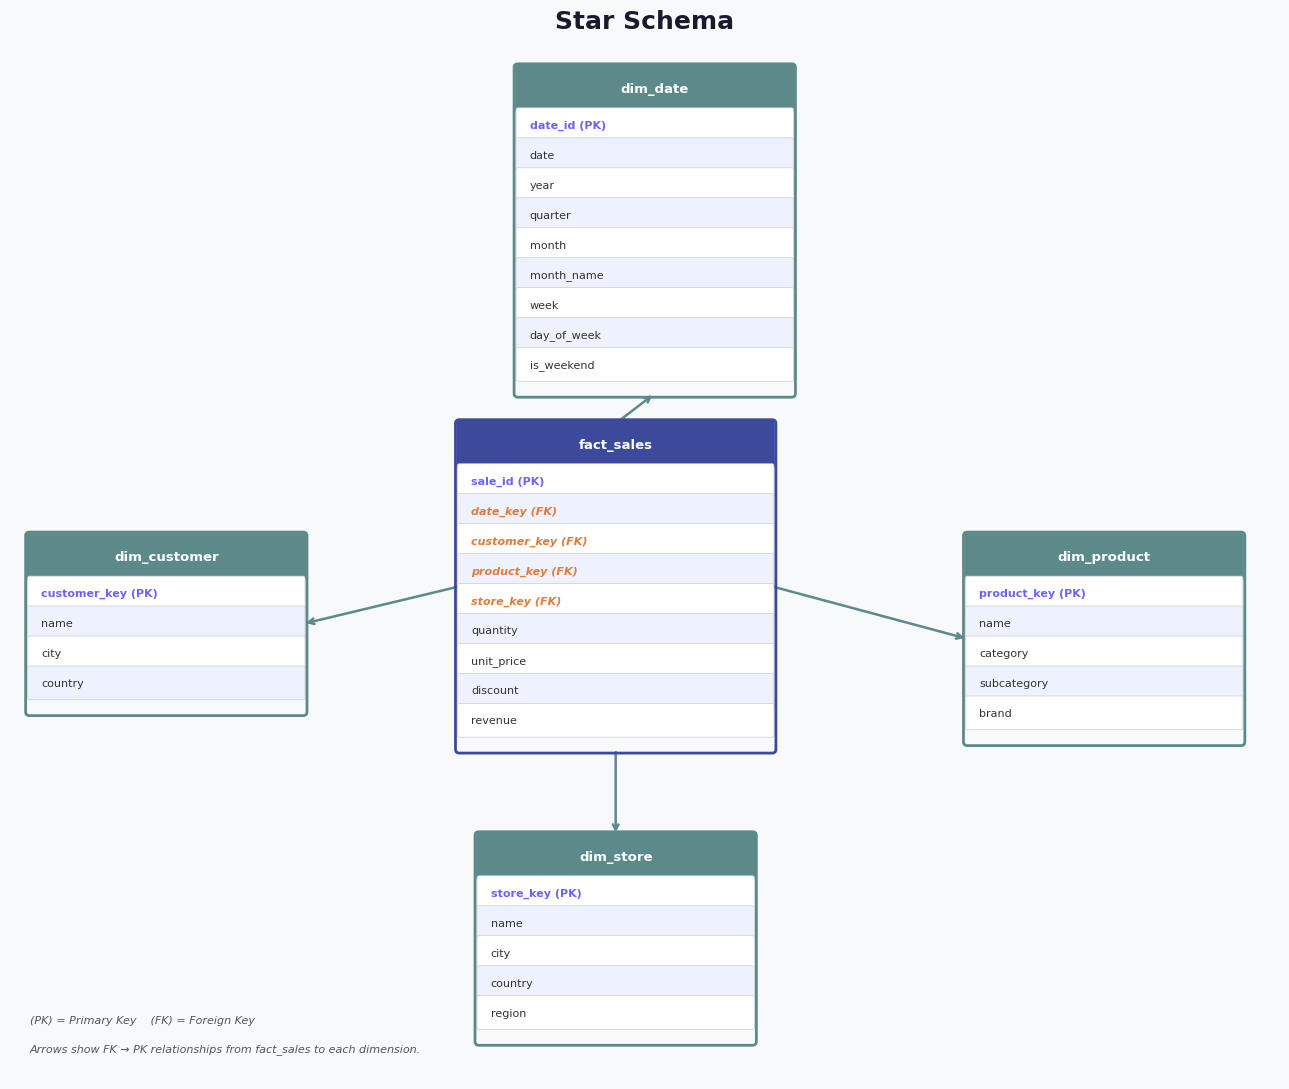

In [7]:
# ── Visualise the Star Schema diagram ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 11))
ax.set_xlim(0, 13)
ax.set_ylim(0, 11)
ax.axis('off')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')
ax.set_title('Star Schema', fontsize=18, fontweight='bold', pad=15, color='#1a1a2e')

def draw_table(ax, x, y, title, columns, color, title_color='white', width=2.8, row_h=0.32):
    """Draw a simple table box with a header and column list."""
    header_h = 0.45
    total_h = header_h + len(columns) * row_h + 0.15
    # Header
    ax.add_patch(FancyBboxPatch((x, y - header_h), width, header_h,
                                boxstyle='round,pad=0.04', facecolor=color,
                                edgecolor='white', linewidth=1.5, zorder=3))
    ax.text(x + width/2, y - header_h/2, title, ha='center', va='center',
            fontsize=9.5, fontweight='bold', color=title_color, zorder=4)
    # Rows
    for i, col in enumerate(columns):
        row_y = y - header_h - (i+1)*row_h
        bg = '#FFFFFF' if i % 2 == 0 else '#EEF2FF'
        ax.add_patch(FancyBboxPatch((x, row_y), width, row_h,
                                    boxstyle='round,pad=0.02', facecolor=bg,
                                    edgecolor='#CCCCCC', linewidth=0.5, zorder=3))
        style = 'bold' if col.endswith('(PK)') or col.endswith('(FK)') else 'normal'
        col_color = '#6C63FF' if '(PK)' in col else ('#E07B39' if '(FK)' in col else '#333333')
        ax.text(x + 0.12, row_y + row_h/2, col, ha='left', va='center',
                fontsize=8, fontstyle='italic' if '(FK)' in col else 'normal',
                fontweight=style, color=col_color, zorder=4)
    # Outer border
    ax.add_patch(FancyBboxPatch((x, y - total_h), width, total_h,
                                boxstyle='round,pad=0.04', fill=False,
                                edgecolor=color, linewidth=2, zorder=5))
    # Return center-bottom and center-top and center-left/right
    cx = x + width/2
    return dict(top=(cx, y), bottom=(cx, y-total_h),
                left=(x, y-total_h/2), right=(x+width, y-total_h/2),
                center=(cx, y-total_h/2))

def arrow(ax, src, dst, color='#888888'):
    ax.annotate('', xy=dst, xytext=src,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.8,
                                connectionstyle='arc3,rad=0.0'), zorder=2)

FACT_COL   = '#3B4A9B'
DIM_COL    = '#5C8A8A'

fact_cols = ['sale_id (PK)', 'date_key (FK)', 'customer_key (FK)',
             'product_key (FK)', 'store_key (FK)',
             'quantity', 'unit_price', 'discount', 'revenue']
date_cols  = ['date_id (PK)', 'date', 'year', 'quarter', 'month',
              'month_name', 'week', 'day_of_week', 'is_weekend']
cust_cols  = ['customer_key (PK)', 'name', 'city', 'country']
prod_cols  = ['product_key (PK)', 'name', 'category', 'subcategory', 'brand']
store_cols = ['store_key (PK)', 'name', 'city', 'country', 'region']

# Positions  (x, y = top-left corner of header)
f  = draw_table(ax, 4.6, 7.0, 'fact_sales',   fact_cols,  FACT_COL, width=3.2)
d  = draw_table(ax, 5.2, 10.8, 'dim_date',    date_cols, DIM_COL, width=2.8)
c  = draw_table(ax, 0.2, 5.8, 'dim_customer', cust_cols,  DIM_COL,  width=2.8)
p  = draw_table(ax, 9.8, 5.8, 'dim_product',  prod_cols,  DIM_COL,  width=2.8)
s  = draw_table(ax, 4.8, 2.6, 'dim_store',    store_cols, DIM_COL,  width=2.8)

arrow(ax, f['top'],   d['bottom'], DIM_COL)
arrow(ax, f['left'],  c['right'],  DIM_COL)
arrow(ax, f['right'], p['left'],   DIM_COL)
arrow(ax, f['bottom'],s['top'],    DIM_COL)

# Legend
ax.text(0.2, 0.6, '(PK) = Primary Key    (FK) = Foreign Key', fontsize=8,
        color='#555555', style='italic')
ax.text(0.2, 0.3,
        'Arrows show FK → PK relationships from fact_sales to each dimension.',
        fontsize=8, color='#555555', style='italic')

plt.tight_layout()
plt.show()

### Why denormalise the dimensions?

In a star schema, `dim_product` keeps `category`, `subcategory`, and `brand` in the **same row** as the product. This means an analyst querying sales by category only needs **one join** (fact → dim_product), not three. The redundancy cost is small compared to the query simplification gain.

| | OLTP (3NF) | Star Schema |
|---|---|---|
| **Primary goal** | Fast writes, data integrity | Fast reads, simple queries |
| **Redundancy** | Minimised | Intentionally allowed in dims |
| **Joins** | Many (3–5+ per query) | Few (1 per dimension) |
| **Aggregations** | Slower | Fast (columnar-friendly) |

---
## 4. Snowflake Schema

The **snowflake schema** is a star schema whose dimension tables have been **partially normalised**. Instead of one flat `dim_product` table, the category hierarchy is split into its own table.

The name comes from the shape: the arms of the star now branch further, resembling a snowflake.

**When does this help?**
- Dimension tables are very large and the repeated strings waste significant storage.
- The hierarchy has many levels (e.g., Region → Country → State → City).
- You need to update hierarchy values without updating every product row.

**The trade-off**: Queries now require an extra join whenever the hierarchy column is needed.

In [8]:
# ── Snowflake Schema tables ───────────────────────────────────────────────────
# We normalize dim_product by splitting out the category hierarchy,
# and dim_store by splitting out geography.

# -- dim_subcategory (leaf of product hierarchy)
dim_subcategory = pd.DataFrame([
    {'subcategory_key': 'SC1', 'subcategory_name': 'Peripherals', 'category_key': 'CAT1'},
    {'subcategory_key': 'SC2', 'subcategory_name': 'Notebooks',   'category_key': 'CAT2'},
    {'subcategory_key': 'SC3', 'subcategory_name': 'Lighting',    'category_key': 'CAT3'},
]).set_index('subcategory_key')

# -- dim_category (parent of subcategory)
dim_category = pd.DataFrame([
    {'category_key': 'CAT1', 'category_name': 'Electronics'},
    {'category_key': 'CAT2', 'category_name': 'Stationery'},
    {'category_key': 'CAT3', 'category_name': 'Furniture'},
]).set_index('category_key')

# -- dim_brand
dim_brand = pd.DataFrame([
    {'brand_key': 'B1', 'brand_name': 'Logitech'},
    {'brand_key': 'B2', 'brand_name': 'Anker'},
    {'brand_key': 'B3', 'brand_name': 'Moleskine'},
    {'brand_key': 'B4', 'brand_name': 'IKEA'},
]).set_index('brand_key')

# -- dim_product_sf  (snowflake version — FKs instead of repeated strings)
dim_product_sf = pd.DataFrame([
    {'product_key': 'P07', 'product_name': 'Wireless Mouse',  'subcategory_key': 'SC1', 'brand_key': 'B1'},
    {'product_key': 'P12', 'product_name': 'USB-C Hub',       'subcategory_key': 'SC1', 'brand_key': 'B2'},
    {'product_key': 'P03', 'product_name': 'Notebook A5',     'subcategory_key': 'SC2', 'brand_key': 'B3'},
    {'product_key': 'P21', 'product_name': 'Desk Lamp LED',   'subcategory_key': 'SC3', 'brand_key': 'B4'},
]).set_index('product_key')

# -- dim_country
dim_country = pd.DataFrame([
    {'country_key': 'DE', 'country_name': 'Germany', 'region': 'EMEA'},
    {'country_key': 'JP', 'country_name': 'Japan',   'region': 'APAC'},
    {'country_key': 'US', 'country_name': 'USA',     'region': 'AMER'},
    {'country_key': 'GH', 'country_name': 'Ghana',   'region': 'EMEA'},
    {'country_key': 'IT', 'country_name': 'Italy',   'region': 'EMEA'},
    {'country_key': 'FR', 'country_name': 'France',  'region': 'EMEA'},
]).set_index('country_key')

# -- dim_store_sf  (snowflake version — country_key FK instead of repeated strings)
dim_store_sf = pd.DataFrame([
    {'store_key': 'S01', 'store_name': 'NYC Flagship',   'city': 'New York', 'country_key': 'US'},
    {'store_key': 'S02', 'store_name': 'Berlin Central', 'city': 'Berlin',   'country_key': 'DE'},
    {'store_key': 'S03', 'store_name': 'Milan Store',    'city': 'Milan',    'country_key': 'IT'},
    {'store_key': 'S04', 'store_name': 'Paris Marais',   'city': 'Paris',    'country_key': 'FR'},
    {'store_key': 'S05', 'store_name': 'Shibuya Store',  'city': 'Tokyo',    'country_key': 'JP'},
    {'store_key': 'S09', 'store_name': 'Accra Mall',     'city': 'Accra',    'country_key': 'GH'},
]).set_index('store_key')

print("=== dim_product_sf (snowflake) ===")
print(dim_product_sf.to_string())
print()
print("=== dim_subcategory ===")
print(dim_subcategory.to_string())
print()
print("=== dim_category ===")
print(dim_category.to_string())
print()
print("=== dim_brand ===")
print(dim_brand.to_string())
print()
print("=== dim_store_sf (snowflake) ===")
print(dim_store_sf.to_string())
print()
print("=== dim_country ===")
print(dim_country.to_string())

=== dim_product_sf (snowflake) ===
               product_name subcategory_key brand_key
product_key                                          
P07          Wireless Mouse             SC1        B1
P12               USB-C Hub             SC1        B2
P03             Notebook A5             SC2        B3
P21           Desk Lamp LED             SC3        B4

=== dim_subcategory ===
                subcategory_name category_key
subcategory_key                              
SC1                  Peripherals         CAT1
SC2                    Notebooks         CAT2
SC3                     Lighting         CAT3

=== dim_category ===
             category_name
category_key              
CAT1           Electronics
CAT2            Stationery
CAT3             Furniture

=== dim_brand ===
          brand_name
brand_key           
B1          Logitech
B2             Anker
B3         Moleskine
B4              IKEA

=== dim_store_sf (snowflake) ===
               store_name      city country_key
st

### Querying the Snowflake Schema

The same question — revenue by category and region — now requires more joins.

In [9]:
# Analytical query on the snowflake schema
# fact → dim_product_sf → dim_subcategory → dim_category
# fact → dim_store_sf   → dim_country

snowflake_query = (
    fact_sales
    # product hierarchy
    .merge(dim_product_sf[['subcategory_key']], left_on='product_key', right_index=True)
    .merge(dim_subcategory[['category_key']],   left_on='subcategory_key', right_index=True)
    .merge(dim_category[['category_name']],     left_on='category_key', right_index=True)
    # store geography
    .merge(dim_store_sf[['country_key']],       left_on='store_key', right_index=True)
    .merge(dim_country[['region']],             left_on='country_key', right_index=True)
    # aggregate
    .groupby(['category_name','region'], as_index=False)['revenue'].sum()
    .sort_values('revenue', ascending=False)
)

print("Revenue by Category × Region (snowflake query)")
print(snowflake_query.to_string(index=False))

# Confirm identical results
star_vals  = star_query.set_index(['category','region'])['revenue'].sort_index()
snow_vals  = snowflake_query.rename(columns={'category_name':'category'})\
                             .set_index(['category','region'])['revenue'].sort_index()
assert star_vals.equals(snow_vals), "Results differ!"
print("\n✓ Results are identical to the star schema query.")

Revenue by Category × Region (snowflake query)
category_name region  revenue
  Electronics   EMEA   153.96
  Electronics   APAC   103.97
    Furniture   EMEA    98.60
   Stationery   AMER    53.12
   Stationery   EMEA    37.50
  Electronics   AMER    28.49

✓ Results are identical to the star schema query.


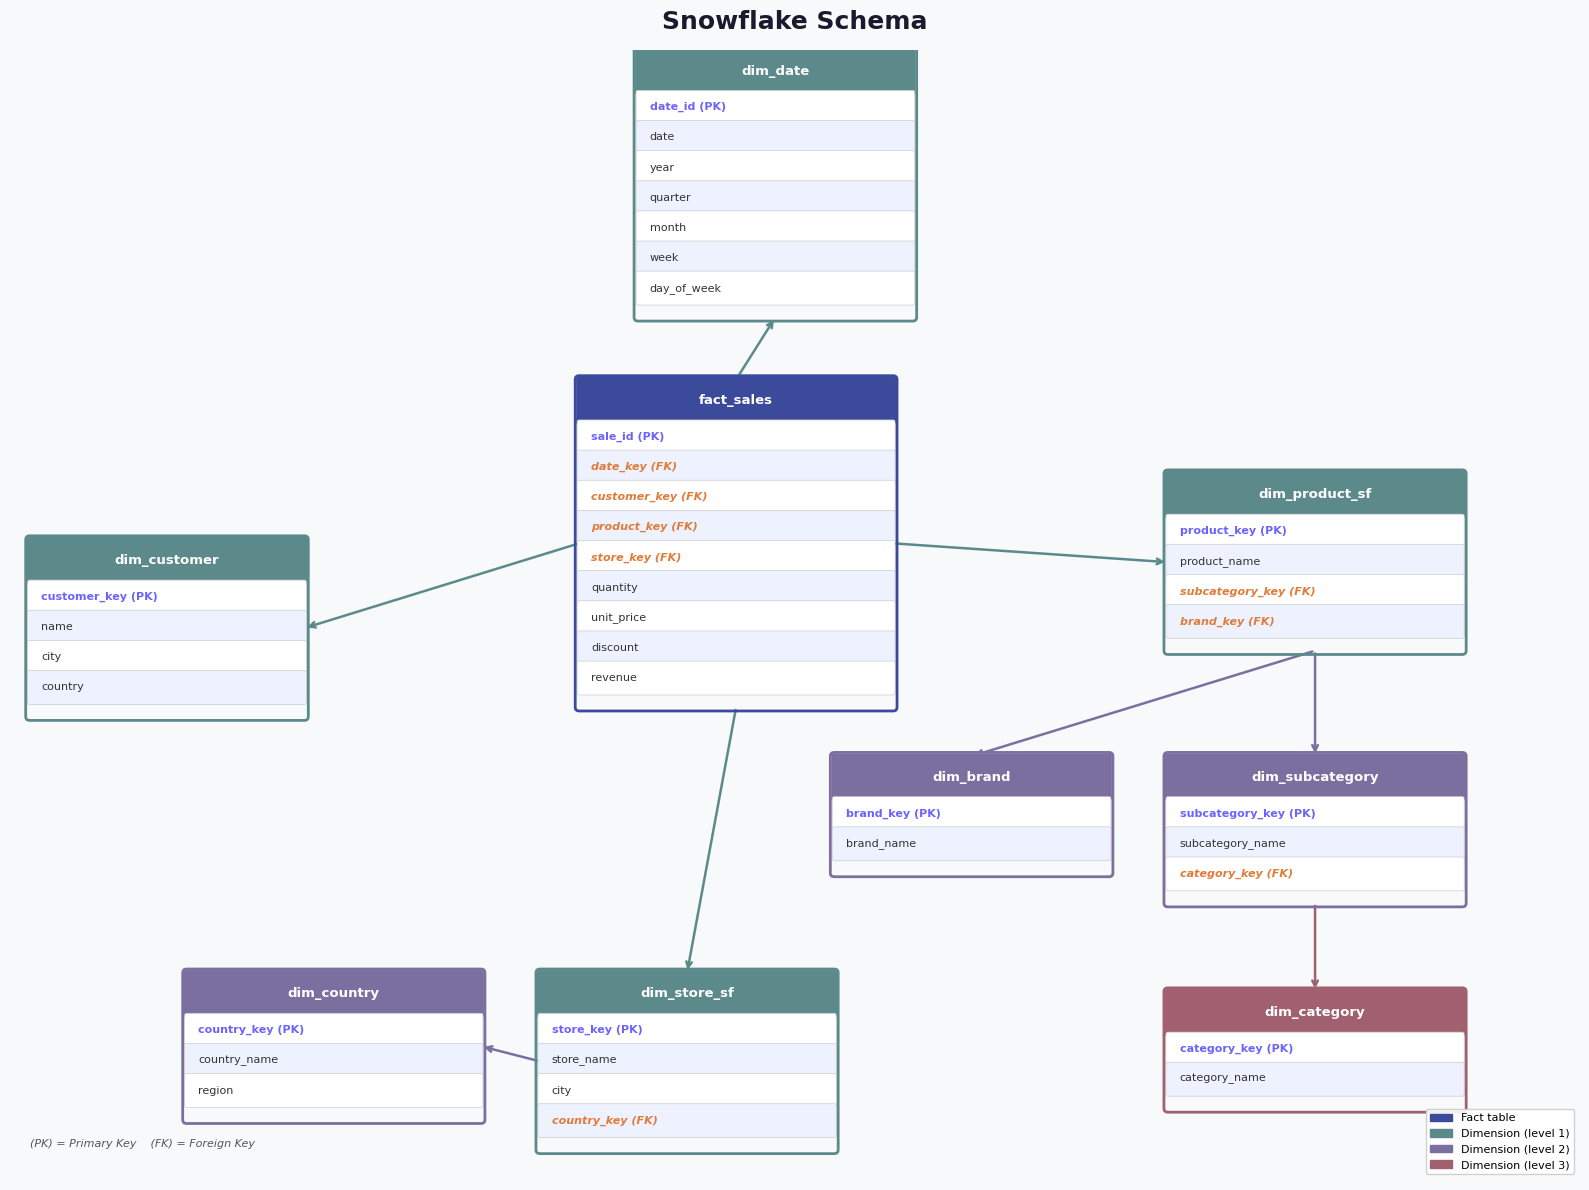

In [11]:
# ── Visualise the Snowflake Schema diagram ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12))
ax.set_xlim(0, 16)
ax.set_ylim(0, 12)
ax.axis('off')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')
ax.set_title('Snowflake Schema', fontsize=18, fontweight='bold', pad=15, color='#1a1a2e')

FACT_COL  = '#3B4A9B'
DIM1_COL  = '#5C8A8A'   # first-level dims
DIM2_COL  = '#7B6FA0'   # second-level (snowflaked)
DIM3_COL  = '#A06070'   # third-level

fact_cols  = ['sale_id (PK)', 'date_key (FK)', 'customer_key (FK)',
              'product_key (FK)', 'store_key (FK)',
              'quantity', 'unit_price', 'discount', 'revenue']
date_cols  = ['date_id (PK)', 'date', 'year', 'quarter',
              'month', 'week', 'day_of_week']
cust_cols  = ['customer_key (PK)', 'name', 'city', 'country']
prod_sf_cols  = ['product_key (PK)', 'product_name',
                 'subcategory_key (FK)', 'brand_key (FK)']
subcat_cols   = ['subcategory_key (PK)', 'subcategory_name', 'category_key (FK)']
cat_cols      = ['category_key (PK)', 'category_name']
brand_cols    = ['brand_key (PK)', 'brand_name']
store_sf_cols = ['store_key (PK)', 'store_name', 'city', 'country_key (FK)']
country_cols  = ['country_key (PK)', 'country_name', 'region']

f  = draw_table(ax, 5.8,  8.5, 'fact_sales',      fact_cols,    FACT_COL, width=3.2)
d  = draw_table(ax, 6.4, 12.0, 'dim_date',        date_cols,    DIM1_COL, width=2.8)
c  = draw_table(ax, 0.2,  6.8, 'dim_customer',    cust_cols,    DIM1_COL, width=2.8)
p  = draw_table(ax, 11.8, 7.5, 'dim_product_sf',  prod_sf_cols, DIM1_COL, width=3.0)
sc = draw_table(ax, 11.8, 4.5, 'dim_subcategory', subcat_cols,  DIM2_COL, width=3.0)
cat= draw_table(ax, 11.8, 2.0, 'dim_category',    cat_cols,     DIM3_COL, width=3.0)
br = draw_table(ax,  8.4, 4.5, 'dim_brand',       brand_cols,   DIM2_COL, width=2.8)
st = draw_table(ax,  5.4, 2.2, 'dim_store_sf',    store_sf_cols,DIM1_COL, width=3.0)
co = draw_table(ax,  1.8, 2.2, 'dim_country',     country_cols, DIM2_COL, width=3.0)

# Arrows: fact → first-level dims
arrow(ax, f['top'],   d['bottom'],  DIM1_COL)
arrow(ax, f['left'],  c['right'],   DIM1_COL)
arrow(ax, f['right'], p['left'],    DIM1_COL)
arrow(ax, f['bottom'],st['top'],    DIM1_COL)
# Arrows: product hierarchy
arrow(ax, p['bottom'], sc['top'],   DIM2_COL)
arrow(ax, p['bottom'], br['top'],   DIM2_COL)
arrow(ax, sc['bottom'],cat['top'],  DIM3_COL)
# Arrows: store geography
arrow(ax, st['left'], co['right'],  DIM2_COL)

# Legend
patches = [
    mpatches.Patch(color=FACT_COL, label='Fact table'),
    mpatches.Patch(color=DIM1_COL, label='Dimension (level 1)'),
    mpatches.Patch(color=DIM2_COL, label='Dimension (level 2)'),
    mpatches.Patch(color=DIM3_COL, label='Dimension (level 3)'),
]
ax.legend(handles=patches, loc='lower right', fontsize=8, framealpha=0.9)
ax.text(0.2, 0.35, '(PK) = Primary Key    (FK) = Foreign Key', fontsize=8,
        color='#555555', style='italic')

plt.tight_layout()
plt.show()

---
## 5. Comparing the Schemas

Let's measure the concrete storage impact of each design on our small dataset.

In [12]:
# ── Storage comparison ─────────────────────────────────────────────────────────
def df_memory(df):
    return df.memory_usage(deep=True).sum()

flat_bytes  = df_memory(flat_sales)

star_bytes  = sum(df_memory(t) for t in [
    fact_sales, dim_date, dim_customer, dim_product, dim_store
])

snow_bytes  = sum(df_memory(t) for t in [
    fact_sales, dim_date, dim_customer,
    dim_product_sf, dim_subcategory, dim_category, dim_brand,
    dim_store_sf, dim_country
])

print(f"Flat table:        {flat_bytes:>6,} bytes  (1 table)")
print(f"Star schema:       {star_bytes:>6,} bytes  (5 tables)")
print(f"Snowflake schema:  {snow_bytes:>6,} bytes  (9 tables)")
print()
print("Note: with only 10 rows overhead dominates. At millions of rows,")
print("removing repeated strings like 'Electronics' and 'EMEA' yields")
print("significant savings in the snowflake schema.")

Flat table:         9,676 bytes  (1 table)
Star schema:        8,749 bytes  (5 tables)
Snowflake schema:  10,579 bytes  (9 tables)

Note: with only 10 rows overhead dominates. At millions of rows,
removing repeated strings like 'Electronics' and 'EMEA' yields
significant savings in the snowflake schema.


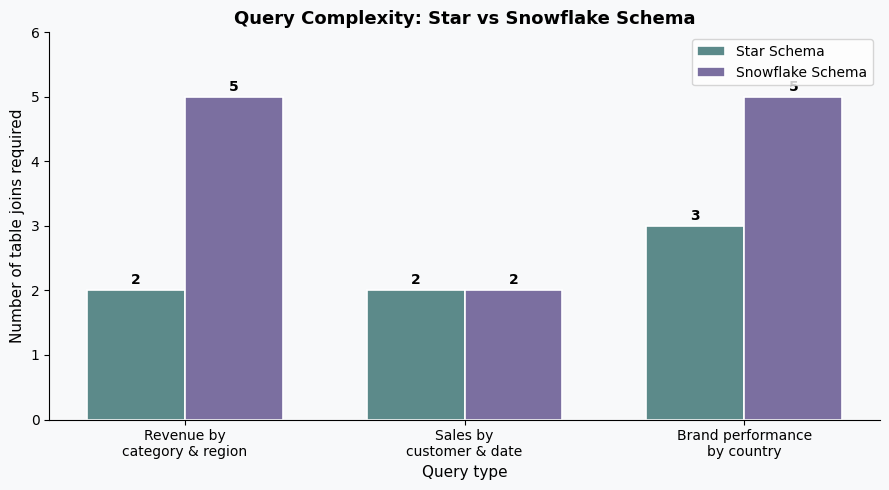

In [13]:
# ── Bar chart: joins required per query type ───────────────────────────────────
query_types = [
    'Revenue by\ncategory & region',
    'Sales by\ncustomer & date',
    'Brand performance\nby country',
]
star_joins  = [2, 2, 3]   # fact+product, fact+customer+date, fact+product+store
snow_joins  = [5, 2, 5]   # product→subcat→cat, same, product→subcat→cat+store→country

x = np.arange(len(query_types))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

bars1 = ax.bar(x - width/2, star_joins, width, label='Star Schema',
               color='#5C8A8A', edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, snow_joins, width, label='Snowflake Schema',
               color='#7B6FA0', edgecolor='white', linewidth=1.2)

ax.set_xlabel('Query type', fontsize=11)
ax.set_ylabel('Number of table joins required', fontsize=11)
ax.set_title('Query Complexity: Star vs Snowflake Schema', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(query_types, fontsize=10)
ax.set_yticks(range(0, 7))
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Summary

### The progression

```
Flat table
    │  Apply normalisation rules (1NF → 2NF → 3NF)
    ▼
Fully normalised (OLTP) — great for writes, painful for analytics
    │  Intentionally denormalise dimensions; keep fact table lean
    ▼
Star Schema — one fact table + flat dimension tables
    │  Normalise large or deep dimension hierarchies
    ▼
Snowflake Schema — one fact table + normalised dimension tables
```

### When to use each

| Schema | Use when… |
|---|---|
| **Star** | Query simplicity is the priority. Dimension tables are manageable in size. Most BI tools and analysts prefer this shape. |
| **Snowflake** | Dimension tables are very large (millions of rows) and the hierarchy values are highly repetitive. You need strict referential integrity on hierarchy levels. |
| **Fully normalised** | You are building a transactional system (OLTP), not a warehouse. Writes and consistency matter more than read speed. |

### Key vocabulary

| Term | Meaning |
|---|---|
| **Fact table** | The central table storing measurable events (sales, orders). Contains FKs + numeric measures. |
| **Dimension table** | A reference table describing *who, what, where, when* of each fact. |
| **Grain** | The level of detail of one row in the fact table (e.g., one line item per sale). |
| **Surrogate key** | An artificial integer PK (e.g., `date_id`) used instead of a natural key. |
| **Conformed dimension** | A dimension shared across multiple fact tables in a data warehouse. |
| **Slowly Changing Dimension (SCD)** | A dimension that tracks changes over time (e.g., a customer who moves city). |